# <font color='seablue'>**Naive Bayes Model**

### <font color='black'>**Learning Objectives**</font>
1. Load and explore datasets using scikit-learn/Pandas, focusing on detecting duplicates and missing values.
2. Clean the dataset by removing duplicates and handling missing feature values.
3. Analyze the dataset for class balance or imbalance.
4. Split the dataset into training and test sets.
5. Preprocess data through feature scaling or standardization for continuous features.
6. Implement Gaussian Naive Bayes from scratch for continuous (numeric) data.
7. Evaluate model performance using accuracy, precision, recall, and confusion matrix.
8. Compare custom Gaussian Naive Bayes implementation with Scikit-learn's GaussianNB.
9. (Bonus) Build a Naive Bayes classifier using Kernel Density Estimation (KDE) instead of a Gaussian assumption.

In [ ]:
# import required packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing
import seaborn as sns

###<font color='pink'>Load and Explore the dataset

In [ ]:
# downloading the Texture dataset from OpenML (data_id=40499)
from sklearn.datasets import fetch_openml

texture = fetch_openml(data_id=40499, as_frame=True)

# Display basic information
print("Features shape:", texture.data.shape)
print("Target shape:", texture.target.shape)
print("Feature names:", texture.feature_names)
print("Target classes:", texture.target.unique())

Features shape: (5500, 40)
Target shape: (5500,)
Feature names: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40']
Target classes: ['5', '6', '7', '11', '1', ..., '8', '10', '2', '3', '4']
Length: 11
Categories (11, object): ['1', '10', '11', '2', ..., '6', '7', '8', '9']


In [ ]:
# combine features and target into a single dataframe for exploration
df = texture.data.copy()
df['class'] = texture.target.astype(int)
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,class
0,-1.223,-0.798,-0.867,-0.639,-0.545,-0.412,-0.795,-0.629,-0.547,-0.868,...,-0.766,-0.555,-0.714,-0.545,-0.587,-0.871,-0.620,-0.568,-0.607,5
1,-1.410,-1.029,-1.013,-0.895,-0.762,-0.676,-1.043,-0.851,-0.775,-1.037,...,-0.919,-0.770,-0.847,-0.663,-0.723,-1.013,-0.748,-0.698,-0.817,5
2,-1.107,-0.649,-0.629,-0.492,-0.367,-0.298,-0.682,-0.478,-0.395,-0.681,...,-0.692,-0.445,-0.588,-0.371,-0.368,-0.746,-0.457,-0.379,-0.469,5
3,-1.270,-0.855,-0.958,-0.707,-0.619,-0.469,-0.872,-0.705,-0.620,-0.988,...,-0.829,-0.719,-0.774,-0.617,-0.688,-0.937,-0.693,-0.657,-0.779,5
4,-1.331,-0.862,-0.761,-0.689,-0.498,-0.361,-0.857,-0.600,-0.496,-0.779,...,-0.861,-0.571,-0.784,-0.545,-0.562,-0.952,-0.642,-0.578,-0.648,5


In [ ]:
df['class'].unique() # 11 classes

array([ 5,  6,  7, 11,  1,  9,  8, 10,  2,  3,  4])

In [ ]:
# Check for duplicate entries
duplicates = df.duplicated()

# Count the number of duplicate entries
num_duplicates = duplicates.sum()

print(f"Number of duplicate entries: {num_duplicates}")

Number of duplicate entries: 27


In [ ]:
# Remove duplicate entries (if any)
df = df.drop_duplicates()

# Verify that duplicates are removed
print(f"Number of duplicate entries after removal: {df.duplicated().sum()}")

Number of duplicate entries after removal: 0


In [ ]:
# Check for missing values
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "No missing values found.")

Missing values in each column:
No missing values found.


In [ ]:
# Remove entries with missing feature values (if any)
df = df.dropna()

# Verify that missing values are removed
print("Missing values after removal:", df.isnull().sum().sum())

Missing values after removal: 0


In [ ]:
#Assign y to the “class” variable and X to the rest of the variables
y = df['class']
X = df.drop('class', axis=1)

# statistical description before scaling
X.describe()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40
count,5473.000000,5473.000000,5473.000000,5473.000000,5473.000000,5473.000000,5473.000000,5473.000000,5473.000000,5473.000000,...,5473.000000,5473.000000,5473.000000,5473.000000,5473.000000,5473.000000,5473.000000,5473.000000,5473.000000,5473.000000
mean,-1.098404,-0.586782,-0.583775,-0.404765,-0.330735,-0.242206,-0.602740,-0.432177,-0.331735,-0.597723,...,-1.098404,-0.646308,-0.491907,-0.643592,-0.491854,-0.593487,-0.779566,-0.554131,-0.523050,-0.567652
std,0.203144,0.205409,0.313410,0.230114,0.235884,0.222452,0.200201,0.221028,0.236013,0.326798,...,0.203144,0.188998,0.330449,0.144083,0.192184,0.170414,0.164110,0.211193,0.201522,0.309178
min,-1.450000,-1.200000,-1.310000,-1.110000,-1.053000,-1.003000,-1.208000,-1.080000,-1.057000,-1.258000,...,-1.450000,-1.179000,-1.147000,-1.123000,-1.015000,-1.030000,-1.253000,-1.097000,-1.076000,-1.215000
25%,-1.218000,-0.712000,-0.771000,-0.534000,-0.480000,-0.345000,-0.720000,-0.584000,-0.484000,-0.828000,...,-1.218000,-0.781000,-0.751000,-0.743000,-0.638000,-0.719000,-0.908000,-0.717000,-0.668000,-0.789000
50%,-1.149000,-0.562000,-0.530000,-0.372000,-0.272000,-0.184000,-0.580000,-0.380000,-0.272000,-0.560000,...,-1.149000,-0.643000,-0.530000,-0.630000,-0.491000,-0.577000,-0.764000,-0.561000,-0.506000,-0.591000
75%,-1.044000,-0.456000,-0.353000,-0.258000,-0.164000,-0.083000,-0.481000,-0.280000,-0.163000,-0.343000,...,-1.044000,-0.542000,-0.253000,-0.559000,-0.338000,-0.464000,-0.686000,-0.397000,-0.368000,-0.345000
max,0.774000,0.330000,0.344000,0.588000,0.439000,0.452000,0.525000,0.398000,0.437000,0.355000,...,0.774000,0.565000,0.675000,0.313000,0.340000,0.156000,0.090000,0.194000,0.202000,0.465000


##### <font color='pink'>For <font color='seablue'>Gaussian Naive Bayes</font>, feature scaling is not strictly required for the algorithm to work (since each feature's mean and variance are estimated per class), but standardizing the features is still good practice here — it keeps the likelihood calculations numerically stable across 40 features that may be on different scales, and it lets us compare our custom implementation against scikit-learn's on equal footing.

##### <font color = 'pink'>As with the categorical case, plotting a full correlation matrix isn't essential for Naive Bayes, since the model assumes features are conditionally independent given the class label — but it's still useful diagnostically to know how strongly that assumption is being violated.

#####<font color='pink'>Check the class distribution of the dataset

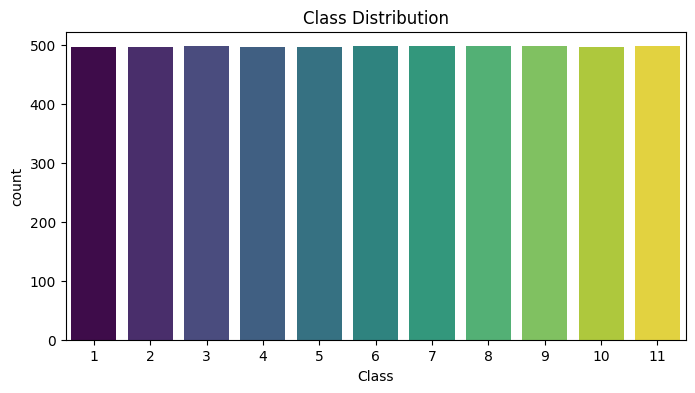

In [ ]:
y.value_counts()
# Set the figure size
plt.figure(figsize=(8, 4))
# Create the count plot
sns.countplot(x=y, hue=y, palette='viridis', legend=False)
plt.title('Class Distribution')
plt.xlabel('Class')
plt.show()

##### <font color='pink'>The Texture dataset turns out to be <font color='seablue'>perfectly balanced</font> — 500 samples in each of the 11 classes. So, we don't need SMOTE or any other resampling technique here; a stratified split is enough to preserve that balance.

### <font color='pink'> Split the dataset into train-test (80-20)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shapes:")
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")

print("\nTest set shapes:")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

# Verify that the split maintains class balance
print("\nClass distribution in training set:")
print(y_train.value_counts().sort_index())

print("\nClass distribution in test set:")
print(y_test.value_counts().sort_index())

Training set shapes:
X_train: (4378, 40)
y_train: (4378,)

Test set shapes:
X_test: (1095, 40)
y_test: (1095,)

Class distribution in training set:
class
1     398
2     398
3     398
4     398
5     398
6     398
7     398
8     398
9     398
10    398
11    398
Name: count, dtype: int64

Class distribution in test set:
class
1      99
2      99
3     100
4      99
5      99
6     100
7     100
8     100
9     100
10     99
11    100
Name: count, dtype: int64


### <font color='pink'> Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# converting to numpy arrays for the from-scratch implementation
y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

print(X_train_scaled.shape, X_test_scaled.shape)

(4378, 40) (1095, 40)


### <font color='pink'> From Scratch Implementation of Gaussian Naive Bayes

##### <font color='pink'>**Idea:** Gaussian NB assumes that, within each class $C$, every feature $x_i$ is drawn from a Normal distribution. So for each class we just need to estimate a mean $\mu_{C,i}$ and variance $\sigma_{C,i}^2$ per feature, then plug into the Gaussian PDF:$$P(x_i \mid C) = \frac{1}{\sqrt{2\pi\sigma_{C,i}^2}} \exp\left(-\frac{(x_i - \mu_{C,i})^2}{2\sigma_{C,i}^2}\right)$$Assuming features are conditionally independent given the class, the class posterior (up to the normalizing constant) is:$$P(C \mid \mathbf{x}) \propto P(C) \prod_{i=1}^{n} P(x_i \mid C)$$We predict the class $C$ that maximizes this. In practice we compute this in **log-space** (sum of log-likelihoods) to avoid numerical underflow from multiplying many small probabilities — though the implementation below multiplies directly since we only have 40 features.

Refer to the video by StatQuest below:
https://youtu.be/H3EjCKtlVog?si=_6L8Or8FUmjxJ1k1

In [ ]:
from scipy.stats import norm

class GaussianNaiveBayes:
    def __init__(self):
        # Initialize storage for priors and per-class feature statistics
        self.classes = None
        self.class_priors = None
        self.means = None
        self.variances = None

    def fit(self, X, y):
        # Identify unique classes and number of features from the training data
        self.classes = np.unique(y)
        n_classes = len(self.classes)
        n_features = X.shape[1]

        self.class_priors = np.zeros(n_classes)
        self.means = np.zeros((n_classes, n_features))
        self.variances = np.zeros((n_classes, n_features))

        for i, c in enumerate(self.classes):
            X_c = X[y == c]
            # Prior probability p(C) based on class frequency
            self.class_priors[i] = len(X_c) / len(X)
            # Per-feature mean and variance p(x|C), assuming a Gaussian distribution
            self.means[i, :] = np.mean(X_c, axis=0)
            self.variances[i, :] = np.var(X_c, axis=0, ddof=1)
            # add small epsilon to avoid division by zero
            self.variances[i, :] = np.maximum(self.variances[i, :], 1e-9)

    def calculate_likelihood(self, X):
        n_samples = X.shape[0]
        n_classes = len(self.classes)
        likelihoods = np.zeros((n_samples, n_classes))

        for i in range(n_classes):
            for j in range(n_samples):
                feature_likelihoods = norm.pdf(X[j, :], self.means[i, :], np.sqrt(self.variances[i, :]))
                likelihoods[j, i] = np.prod(feature_likelihoods)

        return likelihoods

    def predict(self, X):
        likelihoods = self.calculate_likelihood(X)
        posteriors = likelihoods * self.class_priors
        predictions = self.classes[np.argmax(posteriors, axis=1)]
        return predictions

In [ ]:
# create and fit the Gaussian Naive Bayes classifier
gnb_scratch = GaussianNaiveBayes()
gnb_scratch.fit(X_train_scaled, y_train)

### <font color='pink'> Train and Test Results of Custom Gaussian NB

Custom Gaussian Naive Bayes Performance Metrics:
Training Set:
  Accuracy:  0.7812 (78.12%)
  Precision: 0.7832 (78.32%)
  Recall:    0.7812 (78.12%)

Test Set:
  Accuracy:  0.7589 (75.89%)
  Precision: 0.7596 (75.96%)
  Recall:    0.7584 (75.84%)

Classification Report:
              precision    recall  f1-score   support

           1       0.62      0.48      0.54        99
           2       1.00      0.99      0.99        99
           3       0.98      0.98      0.98       100
           4       0.48      0.63      0.54        99
           5       0.67      0.67      0.67        99
           6       0.78      0.80      0.79       100
           7       0.83      0.96      0.89       100
           8       0.71      0.92      0.80       100
           9       1.00      1.00      1.00       100
          10       0.55      0.44      0.49        99
          11       0.73      0.47      0.57       100

    accuracy                           0.76      1095
   macro avg       0.76 

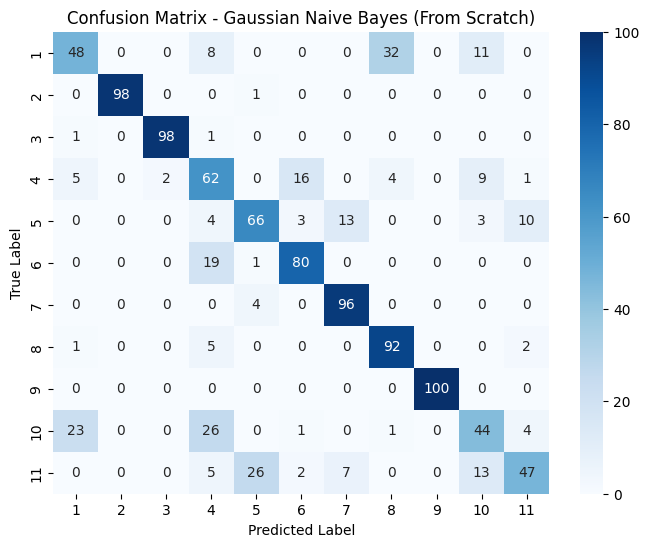

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

# make predictions
y_train_pred = gnb_scratch.predict(X_train_scaled)
y_test_pred = gnb_scratch.predict(X_test_scaled)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

train_precision = precision_score(y_train, y_train_pred, average='macro', zero_division=0)
test_precision = precision_score(y_test, y_test_pred, average='macro', zero_division=0)

train_recall = recall_score(y_train, y_train_pred, average='macro', zero_division=0)
test_recall = recall_score(y_test, y_test_pred, average='macro', zero_division=0)

print("Custom Gaussian Naive Bayes Performance Metrics:")
print("=" * 70)
print(f"Training Set:")
print(f"  Accuracy:  {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"  Precision: {train_precision:.4f} ({train_precision*100:.2f}%)")
print(f"  Recall:    {train_recall:.4f} ({train_recall*100:.2f}%)")

print(f"\nTest Set:")
print(f"  Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"  Precision: {test_precision:.4f} ({test_precision*100:.2f}%)")
print(f"  Recall:    {test_recall:.4f} ({test_recall*100:.2f}%)")

# Generate confusion matrix
cm = confusion_matrix(y_test, y_test_pred, labels=gnb_scratch.classes)
class_names = [str(c) for c in gnb_scratch.classes]

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=class_names))

# Plotting confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Gaussian Naive Bayes (From Scratch)')
plt.show()

### <font color='pink'> Sklearn's Gaussian Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB

# Initialize the GaussianNB classifier
sklearn_gnb = GaussianNB()

# Fit the model on the training data
sklearn_gnb.fit(X_train_scaled, y_train)

# Make predictions on the training and test sets
y_train_pred_sklearn = sklearn_gnb.predict(X_train_scaled)
y_test_pred_sklearn = sklearn_gnb.predict(X_test_scaled)

Scikit-learn Gaussian Naive Bayes Performance Metrics:
Training Set:
  Accuracy:  0.7812 (78.12%)
  Precision: 0.7832 (78.32%)
  Recall:    0.7812 (78.12%)

Test Set:
  Accuracy:  0.7589 (75.89%)
  Precision: 0.7596 (75.96%)
  Recall:    0.7584 (75.84%)


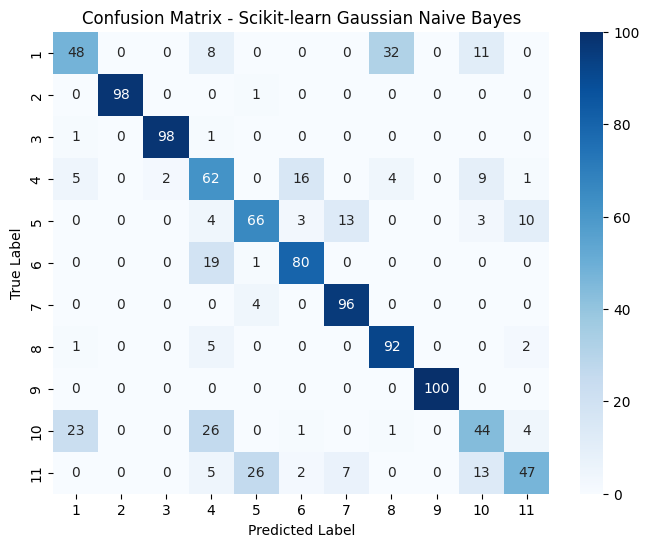

In [ ]:
# Calculate performance metrics
train_accuracy_sklearn = accuracy_score(y_train, y_train_pred_sklearn)
test_accuracy_sklearn = accuracy_score(y_test, y_test_pred_sklearn)

train_precision_sklearn = precision_score(y_train, y_train_pred_sklearn, average='macro', zero_division=0)
test_precision_sklearn = precision_score(y_test, y_test_pred_sklearn, average='macro', zero_division=0)

train_recall_sklearn = recall_score(y_train, y_train_pred_sklearn, average='macro', zero_division=0)
test_recall_sklearn = recall_score(y_test, y_test_pred_sklearn, average='macro', zero_division=0)

print("Scikit-learn Gaussian Naive Bayes Performance Metrics:")
print("=" * 70)
print(f"Training Set:")
print(f"  Accuracy:  {train_accuracy_sklearn:.4f} ({train_accuracy_sklearn*100:.2f}%)")
print(f"  Precision: {train_precision_sklearn:.4f} ({train_precision_sklearn*100:.2f}%)")
print(f"  Recall:    {train_recall_sklearn:.4f} ({train_recall_sklearn*100:.2f}%)")

print(f"\nTest Set:")
print(f"  Accuracy:  {test_accuracy_sklearn:.4f} ({test_accuracy_sklearn*100:.2f}%)")
print(f"  Precision: {test_precision_sklearn:.4f} ({test_precision_sklearn*100:.2f}%)")
print(f"  Recall:    {test_recall_sklearn:.4f} ({test_recall_sklearn*100:.2f}%)")

# Confusion matrix
cm_sklearn = confusion_matrix(y_test, y_test_pred_sklearn, labels=sklearn_gnb.classes_)
class_names_sklearn = [str(c) for c in sklearn_gnb.classes_]

plt.figure(figsize=(8, 6))
sns.heatmap(cm_sklearn, annot=True, fmt='d', cmap='Blues', xticklabels=class_names_sklearn, yticklabels=class_names_sklearn)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Scikit-learn Gaussian Naive Bayes')
plt.show()

##### <font color='pink'>The custom implementation and scikit-learn's <font color='seablue'>GaussianNB</font> should give very similar accuracy, precision, and recall — both are computing the same thing (per-class Gaussian likelihoods times priors), just with different levels of internal optimization. Small differences can come from how ties or numerical underflow are handled.

### <font color='pink'> From Scratch Implementation of Bernoulli Naive Bayes

##### <font color='pink'>**Idea:** Bernoulli NB assumes each feature $x_i$ is a **binary** indicator (0 or 1) rather than continuous. Within each class $C$, feature $i$ is modeled as a coin flip with probability $p_{C,i} = P(x_i = 1 \mid C)$:$$P(x_i \mid C) = p_{C,i}^{\,x_i} \, (1 - p_{C,i})^{\,1 - x_i}$$So a present feature ($x_i=1$) contributes $p_{C,i}$, and an absent feature ($x_i=0$) contributes $(1-p_{C,i})$ — unlike Multinomial NB, Bernoulli NB explicitly penalizes the *absence* of a feature too. The class posterior is again:$$P(C \mid \mathbf{x}) \propto P(C) \prod_{i=1}^{n} P(x_i \mid C)$$Since our Texture features are continuous (not naturally binary), we binarize the **scaled** features at 0 — i.e. $x_i = 1$ if that feature is above its class-agnostic mean, else 0. This throws away magnitude information, so we'd expect Bernoulli NB to do noticeably worse than Gaussian NB here; that's a useful discussion point on when each NB variant fits the data.

In [ ]:
# binarize the scaled features at 0 (mean-threshold, since StandardScaler centers each feature at 0)
X_train_bin = (X_train_scaled > 0).astype(int)
X_test_bin = (X_test_scaled > 0).astype(int)

print("Fraction of 1s in X_train_bin:", X_train_bin.mean())

Fraction of 1s in X_train_bin: 0.5135906806761078


In [ ]:
class BernoulliNaiveBayes:
    def __init__(self, alpha=1.0):
        # alpha is the Laplace (add-alpha) smoothing parameter, avoids zero probabilities
        self.alpha = alpha
        self.classes = None
        self.class_priors = None
        self.feature_probs = None  # P(x_i = 1 | C) for each class, feature

    def fit(self, X, y):
        self.classes = np.unique(y)
        n_classes = len(self.classes)
        n_features = X.shape[1]

        self.class_priors = np.zeros(n_classes)
        self.feature_probs = np.zeros((n_classes, n_features))

        for i, c in enumerate(self.classes):
            X_c = X[y == c]
            # Prior probability p(C) based on class frequency
            self.class_priors[i] = len(X_c) / len(X)
            # p_{C,i} = P(x_i = 1 | C), with Laplace smoothing
            self.feature_probs[i, :] = (X_c.sum(axis=0) + self.alpha) / (len(X_c) + 2 * self.alpha)

    def predict(self, X):
        n_samples = X.shape[0]
        n_classes = len(self.classes)
        log_posteriors = np.zeros((n_samples, n_classes))

        for i in range(n_classes):
            p = self.feature_probs[i, :]
            log_prior = np.log(self.class_priors[i])
            # log P(x|C) = sum_j [ x_j * log(p_j) + (1 - x_j) * log(1 - p_j) ]
            log_likelihood = X @ np.log(p) + (1 - X) @ np.log(1 - p)
            log_posteriors[:, i] = log_prior + log_likelihood

        return self.classes[np.argmax(log_posteriors, axis=1)]

In [ ]:
# create and fit the Bernoulli Naive Bayes classifier
bnb_scratch = BernoulliNaiveBayes(alpha=1.0)
bnb_scratch.fit(X_train_bin, y_train)

### <font color='pink'> Train and Test Results of Custom Bernoulli NB

Custom Bernoulli Naive Bayes Performance Metrics:
Training Set:
  Accuracy:  0.5685 (56.85%)
  Precision: 0.6283 (62.83%)
  Recall:    0.5685 (56.85%)

Test Set:
  Accuracy:  0.5626 (56.26%)
  Precision: 0.6264 (62.64%)
  Recall:    0.5614 (56.14%)

Classification Report:
              precision    recall  f1-score   support

           1       0.59      0.10      0.17        99
           2       0.32      0.10      0.15        99
           3       0.39      0.96      0.56       100
           4       0.62      0.48      0.55        99
           5       0.73      0.44      0.55        99
           6       0.77      0.58      0.66       100
           7       0.35      0.95      0.51       100
           8       0.72      0.73      0.73       100
           9       1.00      1.00      1.00       100
          10       0.62      0.44      0.52        99
          11       0.76      0.38      0.51       100

    accuracy                           0.56      1095
   macro avg       0.63

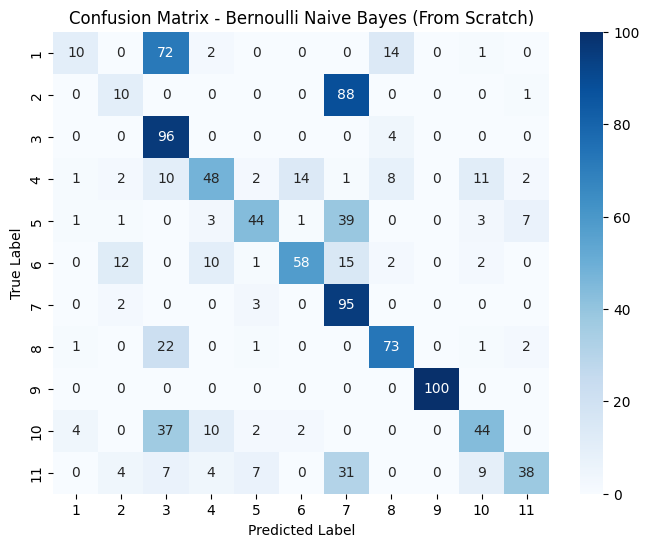

In [ ]:
# make predictions
y_train_pred_bnb = bnb_scratch.predict(X_train_bin)
y_test_pred_bnb = bnb_scratch.predict(X_test_bin)

train_accuracy_bnb = accuracy_score(y_train, y_train_pred_bnb)
test_accuracy_bnb = accuracy_score(y_test, y_test_pred_bnb)

train_precision_bnb = precision_score(y_train, y_train_pred_bnb, average='macro', zero_division=0)
test_precision_bnb = precision_score(y_test, y_test_pred_bnb, average='macro', zero_division=0)

train_recall_bnb = recall_score(y_train, y_train_pred_bnb, average='macro', zero_division=0)
test_recall_bnb = recall_score(y_test, y_test_pred_bnb, average='macro', zero_division=0)

print("Custom Bernoulli Naive Bayes Performance Metrics:")
print("=" * 70)
print(f"Training Set:")
print(f"  Accuracy:  {train_accuracy_bnb:.4f} ({train_accuracy_bnb*100:.2f}%)")
print(f"  Precision: {train_precision_bnb:.4f} ({train_precision_bnb*100:.2f}%)")
print(f"  Recall:    {train_recall_bnb:.4f} ({train_recall_bnb*100:.2f}%)")

print(f"\nTest Set:")
print(f"  Accuracy:  {test_accuracy_bnb:.4f} ({test_accuracy_bnb*100:.2f}%)")
print(f"  Precision: {test_precision_bnb:.4f} ({test_precision_bnb*100:.2f}%)")
print(f"  Recall:    {test_recall_bnb:.4f} ({test_recall_bnb*100:.2f}%)")

# Generate confusion matrix
cm_bnb = confusion_matrix(y_test, y_test_pred_bnb, labels=bnb_scratch.classes)
class_names_bnb = [str(c) for c in bnb_scratch.classes]

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_bnb, target_names=class_names_bnb))

# Plotting confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_bnb, annot=True, fmt='d', cmap='Blues', xticklabels=class_names_bnb, yticklabels=class_names_bnb)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Bernoulli Naive Bayes (From Scratch)')
plt.show()

### <font color='pink'> Sklearn's Bernoulli Naive Bayes

In [ ]:
from sklearn.naive_bayes import BernoulliNB

# Initialize the BernoulliNB classifier (same binarized features, same alpha)
sklearn_bnb = BernoulliNB(alpha=1.0)

# Fit the model on the training data
sklearn_bnb.fit(X_train_bin, y_train)

# Make predictions on the training and test sets
y_train_pred_sklearn_bnb = sklearn_bnb.predict(X_train_bin)
y_test_pred_sklearn_bnb = sklearn_bnb.predict(X_test_bin)

Scikit-learn Bernoulli Naive Bayes Performance Metrics:
Training Set:
  Accuracy:  0.5685 (56.85%)
  Precision: 0.6283 (62.83%)
  Recall:    0.5685 (56.85%)

Test Set:
  Accuracy:  0.5626 (56.26%)
  Precision: 0.6264 (62.64%)
  Recall:    0.5614 (56.14%)


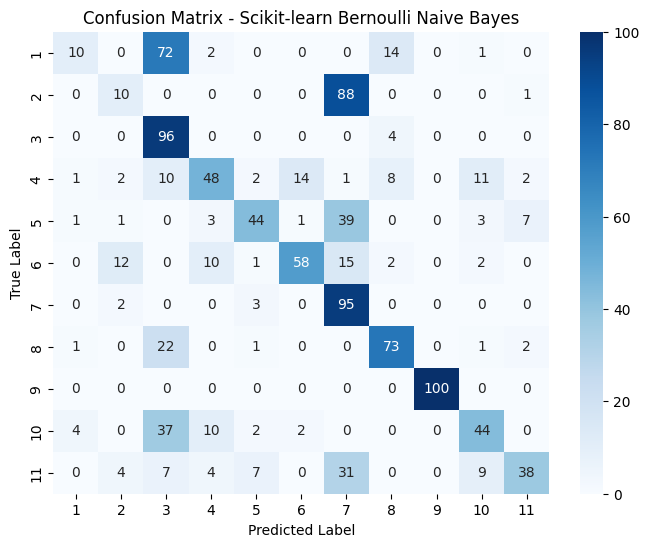

In [ ]:
# Calculate performance metrics
train_accuracy_sklearn_bnb = accuracy_score(y_train, y_train_pred_sklearn_bnb)
test_accuracy_sklearn_bnb = accuracy_score(y_test, y_test_pred_sklearn_bnb)

train_precision_sklearn_bnb = precision_score(y_train, y_train_pred_sklearn_bnb, average='macro', zero_division=0)
test_precision_sklearn_bnb = precision_score(y_test, y_test_pred_sklearn_bnb, average='macro', zero_division=0)

train_recall_sklearn_bnb = recall_score(y_train, y_train_pred_sklearn_bnb, average='macro', zero_division=0)
test_recall_sklearn_bnb = recall_score(y_test, y_test_pred_sklearn_bnb, average='macro', zero_division=0)

print("Scikit-learn Bernoulli Naive Bayes Performance Metrics:")
print("=" * 70)
print(f"Training Set:")
print(f"  Accuracy:  {train_accuracy_sklearn_bnb:.4f} ({train_accuracy_sklearn_bnb*100:.2f}%)")
print(f"  Precision: {train_precision_sklearn_bnb:.4f} ({train_precision_sklearn_bnb*100:.2f}%)")
print(f"  Recall:    {train_recall_sklearn_bnb:.4f} ({train_recall_sklearn_bnb*100:.2f}%)")

print(f"\nTest Set:")
print(f"  Accuracy:  {test_accuracy_sklearn_bnb:.4f} ({test_accuracy_sklearn_bnb*100:.2f}%)")
print(f"  Precision: {test_precision_sklearn_bnb:.4f} ({test_precision_sklearn_bnb*100:.2f}%)")
print(f"  Recall:    {test_recall_sklearn_bnb:.4f} ({test_recall_sklearn_bnb*100:.2f}%)")

# Confusion matrix
cm_sklearn_bnb = confusion_matrix(y_test, y_test_pred_sklearn_bnb, labels=sklearn_bnb.classes_)
class_names_sklearn_bnb = [str(c) for c in sklearn_bnb.classes_]

plt.figure(figsize=(8, 6))
sns.heatmap(cm_sklearn_bnb, annot=True, fmt='d', cmap='Blues', xticklabels=class_names_sklearn_bnb, yticklabels=class_names_sklearn_bnb)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Scikit-learn Bernoulli Naive Bayes')
plt.show()

##### <font color='pink'>Compare this to the Gaussian NB results above — Bernoulli NB only knows whether each feature was above or below its mean, not by how much. On a dataset like Texture where the actual magnitude of each feature carries real information, we'd expect <font color='seablue'>Gaussian NB to outperform Bernoulli NB</font>.

# <font color='seablue'>**Assignment: Multinomial Naive Bayes**
### SMS Spam Classification
**Total Marks: 20**

### <font color = "orange"> Q1. Load the SMS Spam Collection dataset from: https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv (1 Mark)

### <font color = "orange"> Q2. Check for and handle duplicate entries and missing values in the dataset. (2 Marks)

### <font color = "orange"> Q3. Show the class distribution of the dataset and state whether the dataset is well balanced or not. (2 Marks)

### <font color = "orange"> Q4. Preprocess the message text (convert to lowercase and remove punctuation) so it's ready for vectorization. (2 Marks)

### <font color = "orange"> Q5. Split the dataset into training and test sets (80%-20%). (1 Mark)

##### <font color='pink'>We split on the raw text **before** vectorizing, so that the vocabulary used in Q6 is built only from the training set — fitting the vectorizer on the full dataset (train + test) would leak test-set vocabulary into training, which is a subtle form of data leakage.

### <font color = "orange"> Q6. Convert the preprocessed messages into count vectors (bag-of-words) using CountVectorizer, fitting only on the training data. (2 Marks)

##### <font color='pink'>A **bag-of-words** representation turns each message into a vector of word counts against a fixed vocabulary — e.g. the message `"free entry free"` becomes a vector where the column for `"free"` has value 2, `"entry"` has value 1, and every other vocabulary word is 0. This is exactly the kind of count data Multinomial Naive Bayes is built for. We cap the vocabulary size and drop common English stopwords to keep the feature space manageable and focused on informative words.

### <font color = "orange"> Q7. Design a Multinomial Naive Bayes classifier from scratch and fit it on the training set. (6 Marks)

##### <font color='pink'>**Idea:** Multinomial NB models each class $C$ as having its own word-usage distribution — feature $i$ (word $i$) occurs with probability $p_{C,i}$ within class $C$'s documents. For a document with word counts $x_1, \ldots, x_n$, the likelihood is:$$P(\mathbf{x} \mid C) \;\propto\; \prod_{i=1}^{n} p_{C,i}^{\,x_i}$$(The multinomial coefficient $\frac{(\sum_i x_i)!}{\prod_i x_i!}$ is dropped since it's the same for every class and doesn't affect which class has the highest posterior.) We estimate $p_{C,i}$ from training data with **Laplace (add-$\alpha$) smoothing**, so a word that never appeared in class $C$'s training documents doesn't get assigned zero probability:$$p_{C,i} = \frac{N_{C,i} + \alpha}{N_C + \alpha n}$$where $N_{C,i}$ is the total count of word $i$ across all class-$C$ documents, $N_C$ is the total word count across all class-$C$ documents, and $n$ is the vocabulary size. Combined with the class prior $P(C)$, we predict the class maximizing (in log-space, to avoid underflow):$$\log P(C \mid \mathbf{x}) \;\propto\; \log P(C) + \sum_{i=1}^{n} x_i \log p_{C,i}$$

### <font color = "orange"> Q8. Evaluate the test set using your custom Multinomial NB classifier and report accuracy, precision, recall, and confusion matrix. (2 Marks)

### <font color = "orange"> Q9. Using scikit-learn's implementation of Multinomial NB, fit the training data and evaluate on the test set. How does the performance of this model compare with your custom implementation? (2 Marks)